# LexAR - Fases 1 y 2

Notebook de trabajo para implementar las primeras dos fases del proyecto:

1. **Consolidacion de datos:** cargar el corpus procesado, unir metadatos y segmentar textos normativos en fragmentos comparables.
2. **Embeddings y busqueda:** generar representaciones vectoriales semanticas (Vertex AI, `gemini-embedding-001`), recuperar vecinos cercanos y armar candidatos para el analisis posterior de redundancias/contradicciones.

La salida de este notebook no afirma contradicciones juridicas. Produce candidatos semanticamente cercanos para revisar en la fase siguiente con un LLM o evaluacion humana.

Corre sobre el corpus completo (`data/lexar_datos_infoleg_saij/`, ver `README.md`) y usa Vertex AI con los
creditos GCP de la universidad para los embeddings. El baseline de hashing de la primera version del
notebook se conserva como comparacion (seccion 2.3).

## 0. Dependencias

Instalar dependencias desde `requirements.txt` en la raiz del repo (incluye `pyarrow` para leer el
`.parquet` del corpus, `google-genai` para Vertex AI, `faiss-cpu` para la busqueda de vecinos, y
`scikit-learn`/`matplotlib` para la reduccion de dimensionalidad).

In [1]:
# Ejecutar solo si faltan dependencias.
# %pip install -r ../requirements.txt

In [2]:
from __future__ import annotations

import gc
import hashlib
import importlib.util
import json
import math
import os
import re
import time
from collections import defaultdict, deque
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if importlib.util.find_spec("pyarrow") is None:
    raise RuntimeError("Falta pyarrow. Ejecutar la celda de dependencias: %pip install -r ../requirements.txt")

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 220)

## 1. Configuracion

`MAX_TEXT_VERSIONS` y `MAX_FRAGMENTS_FOR_EMBEDDINGS` en `None` procesan el corpus completo. Bajarlos a un
numero chico (ej. 200) para una corrida de prueba barata antes de lanzar el run completo contra Vertex AI.

In [3]:
ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    # Soporta lanzar Jupyter tanto desde la raiz del repo como desde notebooks/.
    ROOT = ROOT.parent

DATASET_DIR = ROOT / "data" / "lexar_datos_infoleg_saij"
TEXT_VERSIONS_PATH = DATASET_DIR / "corpus_unificado" / "text_versions.parquet"
DOCUMENTS_PATH = DATASET_DIR / "infoleg" / "procesado" / "documents.csv"
RELATIONS_PATH = DATASET_DIR / "infoleg" / "procesado" / "relations.csv"
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# None = procesar todo el corpus. Bajar estos valores para una corrida de prueba barata.
MAX_TEXT_VERSIONS = None
MAX_FRAGMENTS_FOR_EMBEDDINGS = None

# Segmentacion.
MIN_FRAGMENT_CHARS = 80
MAX_FRAGMENT_CHARS = 2_500
CHUNK_OVERLAP_CHARS = 250

# Embeddings semanticos via Vertex AI (usa los creditos GCP de la universidad).
# Proyecto GCP con Vertex AI habilitado y los creditos UDESA vinculados (ver README.md).
# Toma GOOGLE_CLOUD_PROJECT del entorno si esta seteada; si no, usa el default de abajo.
GCP_PROJECT = os.environ.get("GOOGLE_CLOUD_PROJECT", "lexar-501717")
GCP_LOCATION = "us-central1"
EMBEDDING_MODEL = "gemini-embedding-001"
EMBEDDING_DIM = 768  # truncado via Matryoshka Representation Learning (maximo nativo: 3072)
EMBEDDING_BATCH_SIZE = 32
EMBEDDING_MAX_WORKERS = 5  # arranque conservador; el rate limiter adaptativo ajusta el resto
CHECKPOINT_EVERY = 20  # guarda a disco cada N batches (~640 fragmentos con el batch size de arriba)

# Embeddings locales por hashing. Baseline offline solo para comparacion (seccion 2.3).
N_HASH_FEATURES = 512

TOP_K_NEIGHBORS = 8
RANDOM_SEED = 42

assert TEXT_VERSIONS_PATH.exists(), TEXT_VERSIONS_PATH
assert DOCUMENTS_PATH.exists(), DOCUMENTS_PATH

TEXT_VERSIONS_PATH, DOCUMENTS_PATH, OUTPUT_DIR

(WindowsPath('C:/Users/Lucas/documents/projects/tpsudesa/NLP/LexAr/data/lexar_datos_infoleg_saij/corpus_unificado/text_versions.parquet'),
 WindowsPath('C:/Users/Lucas/documents/projects/tpsudesa/NLP/LexAr/data/lexar_datos_infoleg_saij/infoleg/procesado/documents.csv'),
 WindowsPath('C:/Users/Lucas/documents/projects/tpsudesa/NLP/LexAr/outputs'))

## Fase 1 - Consolidacion de datos

Se carga la tabla unificada de textos (`text_versions.parquet`) y se une con los metadatos principales de Infoleg. La tabla resultante conserva trazabilidad hacia `document_id`, fuente, version y datos bibliograficos basicos.

In [4]:
text_versions = pd.read_parquet(TEXT_VERSIONS_PATH)
documents = pd.read_csv(DOCUMENTS_PATH, dtype=str, keep_default_na=False)

print(f"Text versions: {len(text_versions):,}")
print(f"Documentos metadata: {len(documents):,}")

display(text_versions.head(3))
display(documents.head(3))

Text versions: 9,518
Documentos metadata: 30,061


,text_version_id,document_id,text_source,version_type,source_url,full_text,full_text_len,articulos_detected,text_hash,source_status,fetched_at,raw_ref,quality_flag
0,infoleg:1|original,infoleg:1,infoleg,original,http://servicios.infoleg.gob.ar/infolegInternet/anexos/0-4999/1/norma.htm,EXPROPIACIONES\nLey N° 23.600\nDeclárase de utilidad pública y sujeto a expropiación un inmueble destinado al Poder Judicial de la Nación.\nSancionada: agosto 31 de 1988.\nPromulgada: setiembre 15 de 1988.\nEl Senado...,1238,5,3b45bda9e31e0f1cd28d4824b72d55efc60cc7e2d233217b0eb2b52ec19d12d9,ok,2026-06-25T17:09:30.099566+00:00,data\raw\infoleg\html\1\norma.htm,clean
1,infoleg:2|original,infoleg:2,infoleg,original,http://servicios.infoleg.gob.ar/infolegInternet/anexos/0-4999/2/norma.htm,"CONDECORACIONES\nLEY N° 23.601\nAutorízase a recibir y a usar una condecoración, a un ciudadano.\nSancionada: agosto 31 de 1988.\nPromulgada: setiembre 22 de 1988.\nEl Senado y Cámara de Diputados de la Nación Argent...",851,2,68c63226ea85c06295286e6f161a55e20e0c8d059c5e49407e43d365e685a4a4,ok,2026-06-25T17:09:30.584028+00:00,data\raw\infoleg\html\2\norma.htm,clean
2,infoleg:3|original,infoleg:3,infoleg,original,http://servicios.infoleg.gob.ar/infolegInternet/anexos/0-4999/3/norma.htm,CONDECORACIONES\nLEY N° 23.602\nAutorízase a un ciudadano a aceptar y usar una condecoración.\nSancionada: agosto 31 de 1988.\nPromulgada: Setiembre 22 de 1988.\nEl Senado y Cámara de Diputados de la Nación Argentina...,769,2,129e6dc45c3e03ad4cdf3723c984e8f263b0d86c9f8d7ed396754fbe5fe98e90,ok,2026-06-25T17:09:31.006897+00:00,data\raw\infoleg\html\3\norma.htm,clean


,document_id,infoleg_id_norma,tipo_norma,clase_norma,fecha_sancion,numero_boletin,fecha_boletin,pagina_boletin,titulo_resumido,titulo_sumario,texto_resumido,observaciones,texto_original_url,texto_actualizado_url,has_texto_original,has_texto_actualizado,raw_row_count,raw_first_row_number
0,infoleg:1,1,Ley,,1988-08-31,26479,1988-10-04,1,INMUEBLE DESTINADO PODER JUDICIAL DE LA NACION UBICADO EN LAVALLE 1240 AL 1250,EXPROPIACIONES,DECLARASE DE UTILIDAD PUBLICA Y SUJETO A EXPROPIACION UN INMUEBLE DESTINADO PODER JUDICIAL DE LA NACION UBICADO EN LAVALLE 1240 AL 1250 DE C.F.,,http://servicios.infoleg.gob.ar/infolegInternet/anexos/0-4999/1/norma.htm,,1,0,1,39804
1,infoleg:2,2,Ley,,1988-08-31,26476,1988-09-29,1,AUTORIZACION,CONDECORACIONES,SE AUTORIZA A UN CIUDADANO A RECIBIR Y USAR UNA CONDECORACION.,,http://servicios.infoleg.gob.ar/infolegInternet/anexos/0-4999/2/norma.htm,,1,0,1,39806
2,infoleg:3,3,Ley,,1988-08-31,26476,1988-09-29,1,AUTORIZACION,CONDECORACIONES,AUTORIZASE A UN CIUDADANO A ACEPTAR Y USAR UNA CONDECORACION.,,http://servicios.infoleg.gob.ar/infolegInternet/anexos/0-4999/3/norma.htm,,1,0,1,39802


In [5]:
metadata_cols = [
    "document_id",
    "tipo_norma",
    "clase_norma",
    "fecha_sancion",
    "numero_boletin",
    "fecha_boletin",
    "titulo_resumido",
    "titulo_sumario",
    "texto_resumido",
]

corpus = text_versions.merge(documents[metadata_cols], on="document_id", how="left")
print(f"Filas tras el join (una fila por version de texto): {len(corpus):,}")

Filas tras el join (una fila por version de texto): 9,518


### 1.1 Seleccion de version por documento

Algunos documentos tienen mas de una version de texto (`original` y `actualizado`). Para evitar que la
misma norma aparezca dos veces y genere candidatos triviales entre sus propias versiones, nos quedamos con
una sola version por `document_id`: `actualizado` cuando existe (es el texto vigente), o la unica version
disponible en caso contrario.

In [6]:
version_priority = {"actualizado": 0, "original": 1, "saij": 1}
corpus["version_priority"] = corpus["version_type"].map(version_priority).fillna(2)

corpus_by_document = (
    corpus.sort_values(["document_id", "version_priority"])
    .drop_duplicates("document_id", keep="first")
    .drop(columns="version_priority")
    .reset_index(drop=True)
)

print(f"Documentos unicos tras elegir 'actualizado' cuando existe: {len(corpus_by_document):,}")
print(corpus_by_document["version_type"].value_counts().to_dict())

if MAX_TEXT_VERSIONS is not None and len(corpus_by_document) > MAX_TEXT_VERSIONS:
    corpus_sample = corpus_by_document.sample(MAX_TEXT_VERSIONS, random_state=RANDOM_SEED).reset_index(drop=True)
else:
    corpus_sample = corpus_by_document.reset_index(drop=True)

coverage = {
    "text_versions_total": int(len(text_versions)),
    "documents_total": int(len(documents)),
    "corpus_rows_after_join": int(len(corpus)),
    "corpus_unique_documents": int(len(corpus_by_document)),
    "corpus_sample_rows": int(len(corpus_sample)),
    "sources_in_sample": corpus_sample["text_source"].value_counts().to_dict(),
}

print(json.dumps(coverage, indent=2, ensure_ascii=False))

# Liberar tablas intermedias grandes -- solo corpus_sample sigue haciendo falta de aca en adelante.
del text_versions, documents, corpus, corpus_by_document
gc.collect()

Documentos unicos tras elegir 'actualizado' cuando existe: 8,887
{'original': 7881, 'actualizado': 803, 'saij': 203}
{
  "text_versions_total": 9518,
  "documents_total": 30061,
  "corpus_rows_after_join": 9518,
  "corpus_unique_documents": 8887,
  "corpus_sample_rows": 8887,
  "sources_in_sample": {
    "infoleg": 8684,
    "saij": 203
  }
}


33

### 1.2 Segmentacion en articulos y chunks

La unidad ideal es el articulo. Cuando el patron de articulos no aparece o un articulo queda demasiado largo, el notebook usa chunks con solapamiento como fallback. Esto evita perder textos largos como codigos o compilaciones.

In [7]:
ARTICLE_PATTERN = re.compile(
    r"(?m)^\s*(?:\*+\s*)?ARTICULO\s+([0-9]+|[IVXLCDM]+|[A-Z]+)(?:\s*[.º-])?",
)

TOKEN_PATTERN = re.compile(r"[a-zA-ZáéíóúñÁÉÍÓÚÑ0-9]{3,}")


def normalize_for_article_detection(text: str) -> str:
    """Normaliza solo para detectar encabezados; conserva largo y posiciones."""
    return (
        text.upper()
        .replace("Á", "A")
        .replace("É", "E")
        .replace("Í", "I")
        .replace("Ó", "O")
        .replace("Ú", "U")
        .replace("Ü", "U")
    )


def clean_fragment_text(text: str) -> str:
    text = re.sub(r"\s+", " ", str(text)).strip()
    return text


def chunk_text(text: str, max_chars: int = MAX_FRAGMENT_CHARS, overlap: int = CHUNK_OVERLAP_CHARS):
    text = str(text)
    if len(text) <= max_chars:
        yield 0, len(text), clean_fragment_text(text)
        return

    start = 0
    while start < len(text):
        end = min(start + max_chars, len(text))
        if end < len(text):
            boundary = max(text.rfind(". ", start, end), text.rfind("\n", start, end))
            if boundary > start + max_chars * 0.5:
                end = boundary + 1
        chunk = clean_fragment_text(text[start:end])
        if len(chunk) >= MIN_FRAGMENT_CHARS:
            yield start, end, chunk
        if end >= len(text):
            break
        start = max(0, end - overlap)


def segment_text_version(row: pd.Series) -> list[dict]:
    text = str(row.get("full_text", ""))
    normalized = normalize_for_article_detection(text)
    matches = list(ARTICLE_PATTERN.finditer(normalized))
    fragments = []

    if len(matches) >= 2:
        spans = []
        for index, match in enumerate(matches):
            start = match.start()
            end = matches[index + 1].start() if index + 1 < len(matches) else len(text)
            label = f"ARTICULO {match.group(1)}"
            spans.append((start, end, label))

        for article_index, (start, end, label) in enumerate(spans, start=1):
            article_text = clean_fragment_text(text[start:end])
            if len(article_text) < MIN_FRAGMENT_CHARS:
                continue
            if len(article_text) <= MAX_FRAGMENT_CHARS:
                fragments.append({
                    "fragment_type": "article",
                    "ordinal": article_index,
                    "label": label,
                    "char_start": start,
                    "char_end": end,
                    "text": article_text,
                })
            else:
                for chunk_index, (chunk_start, chunk_end, chunk) in enumerate(chunk_text(article_text), start=1):
                    fragments.append({
                        "fragment_type": "article_chunk",
                        "ordinal": article_index,
                        "label": f"{label} / CHUNK {chunk_index}",
                        "char_start": start + chunk_start,
                        "char_end": start + chunk_end,
                        "text": chunk,
                    })
    else:
        for chunk_index, (start, end, chunk) in enumerate(chunk_text(text), start=1):
            fragments.append({
                "fragment_type": "chunk",
                "ordinal": chunk_index,
                "label": f"CHUNK {chunk_index}",
                "char_start": start,
                "char_end": end,
                "text": chunk,
            })

    for fragment in fragments:
        fragment.update({
            "text_version_id": row.get("text_version_id"),
            "document_id": row.get("document_id"),
            "text_source": row.get("text_source"),
            "version_type": row.get("version_type"),
            "fecha_sancion": row.get("fecha_sancion"),
            "tipo_norma": row.get("tipo_norma"),
            "titulo_resumido": row.get("titulo_resumido"),
            "source_url": row.get("source_url"),
        })
        content_hash = hashlib.sha256(fragment["text"].encode("utf-8", errors="ignore")).hexdigest()
        fragment["content_hash"] = content_hash
        fragment["text_len"] = len(fragment["text"])

    return fragments

In [8]:
all_fragments = []

for _, row in corpus_sample.iterrows():
    all_fragments.extend(segment_text_version(row))

fragments = pd.DataFrame(all_fragments)
if not fragments.empty:
    fragments = fragments.reset_index(drop=True)
    fragments.insert(0, "fragment_id", [f"frag:{i:08d}" for i in range(len(fragments))])

print(f"Fragmentos generados: {len(fragments):,}")
display(fragments.head(10))

# Liberar corpus_sample y la lista cruda -- ya estan volcados en `fragments`.
del corpus_sample, all_fragments
gc.collect()

Fragmentos generados: 113,895


,fragment_id,fragment_type,ordinal,label,char_start,char_end,text,text_version_id,document_id,text_source,version_type,fecha_sancion,tipo_norma,titulo_resumido,source_url,content_hash,text_len
0,frag:00000000,chunk,1,CHUNK 1,0,1238,EXPROPIACIONES Ley N° 23.600 Declárase de utilidad pública y sujeto a expropiación un inmueble destinado al Poder Judicial de la Nación. Sancionada: agosto 31 de 1988. Promulgada: setiembre 15 de 1988. El Senado y Cá...,infoleg:1|original,infoleg:1,infoleg,original,1988-08-31,Ley,INMUEBLE DESTINADO PODER JUDICIAL DE LA NACION UBICADO EN LAVALLE 1240 AL 1250,http://servicios.infoleg.gob.ar/infolegInternet/anexos/0-4999/1/norma.htm,94e8d3f5c9bbc9f2692a6a643e64fdd7207f47bbd685e05cdff8f7d240bc227e,1238
1,frag:00000001,article,1,ARTICULO 1,437,744,"ARTICULO 1º — Apruébase el ACUERDO SOBRE COOPERACION MINERA ENTRE LA REPUBLICA ARGENTINA Y LA REPUBLICA BOLIVARIANA DE VENEZUELA, suscripto en Caracas —REPUBLICA BOLIVARIANA DE VENEZUELA— el 12 de julio de 2000, que ...",infoleg:100016|original,infoleg:100016,infoleg,original,2004-09-22,Ley,COOPERACION MINERA (VENEZUELA),http://servicios.infoleg.gob.ar/infolegInternet/anexos/100000-104999/100016/norma.htm,ea5af779f4b58efb617c8f8c92562df017bd8b9ceea4a18abeb0dab983e077f6,306
2,frag:00000002,article,2,ARTICULO 2,744,2084,"ARTICULO 2º — Comuníquese al Poder Ejecutivo nacional. DADA EN LA SALA DE SESIONES DEL CONGRESO ARGENTINO, EN BUENOS AIRES, A LOS VEINTIDOS DIAS DEL MES DE SEPTIEMBRE DEL AÑO DOS MIL CUATRO. — REGISTRADO BAJO EL Nº 2...",infoleg:100016|original,infoleg:100016,infoleg,original,2004-09-22,Ley,COOPERACION MINERA (VENEZUELA),http://servicios.infoleg.gob.ar/infolegInternet/anexos/100000-104999/100016/norma.htm,1f8b2c39c1062ed4f74c09d248f123855afc38743c7b34dec5b9bd4ecd465aa6,1339
3,frag:00000003,article,3,ARTICULO PRIMERO,2084,2824,"ARTICULO PRIMERO Las Partes convienen en alentar la concreción de programas y proyectos específicos de cooperación en las áreas de minerales metalíferos, no metalíferos, rocas de aplicación y concentrados metalúrgico...",infoleg:100016|original,infoleg:100016,infoleg,original,2004-09-22,Ley,COOPERACION MINERA (VENEZUELA),http://servicios.infoleg.gob.ar/infolegInternet/anexos/100000-104999/100016/norma.htm,bf2e26906eec9cefd718a8ba8bbc5439517030fb034099add5b89ef17bf53fa3,739
4,frag:00000004,article,4,ARTICULO SEGUNDO,2824,3177,"ARTICULO SEGUNDO En ese sentido, las Partes acuerdan poner en marcha un Programa de Cooperación Científico- Técnica, entre la Subsecretaría de Minería de la República Argentina y el Ministerio de Energía y Minas de l...",infoleg:100016|original,infoleg:100016,infoleg,original,2004-09-22,Ley,COOPERACION MINERA (VENEZUELA),http://servicios.infoleg.gob.ar/infolegInternet/anexos/100000-104999/100016/norma.htm,63c12cf1517c376572fdd7daa53385d099e9b87bc27d0b4a6982201064d585f2,352
5,frag:00000005,article,5,ARTICULO TERCERO,3177,3360,"ARTICULO TERCERO Las Partes se comprometen a establecer un Programa de Acción destinado a materializar y complementar, según sea el caso, lo establecido en los artículos precedentes.",infoleg:100016|original,infoleg:100016,infoleg,original,2004-09-22,Ley,COOPERACION MINERA (VENEZUELA),http://servicios.infoleg.gob.ar/infolegInternet/anexos/100000-104999/100016/norma.htm,1156e5fd6f1d62005f0e0bc43f87b08a1d7194be4315d1dde427fd7d83e21620,182
6,frag:00000006,article,6,ARTICULO C,3360,4080,"ARTICULO CUARTO El Programa de Acción mencionado en el artículo precedente se referirá a los aspectos vinculados con: a) el marco legal de las inversiones del sector, b) el estudio e investigación de los avances legi...",infoleg:100016|original,infoleg:100016,infoleg,original,2004-09-22,Ley,COOPERACION MINERA (VENEZUELA),http://servicios.infoleg.gob.ar/infolegInternet/anexos/100000-104999/100016/norma.htm,e8b49c1b7999671132fe0520e973f038cc3e994577c9b3891f895431f3196cf0,719
7,frag:00000007,article,7,ARTICULO QUINTO,4080,4772,"ARTICULO QUINTO Las actividades previstas en el Programa de Acción incluirán

0

In [9]:
fragment_profile = {
    "fragments_total": int(len(fragments)),
    "documents_total": int(fragments["document_id"].nunique()) if not fragments.empty else 0,
    "by_fragment_type": fragments["fragment_type"].value_counts().to_dict() if not fragments.empty else {},
    "text_len_stats": fragments["text_len"].describe().round(2).to_dict() if not fragments.empty else {},
}

print(json.dumps(fragment_profile, indent=2, ensure_ascii=False))

fragments_path = OUTPUT_DIR / "legal_fragments.parquet"
fragments.to_parquet(fragments_path, index=False)

# CSV chico solo para inspeccion rapida (el corpus completo en CSV pesa demasiado).
fragments_sample_path = OUTPUT_DIR / "legal_fragments_sample.csv"
fragments.head(2_000).to_csv(fragments_sample_path, index=False, encoding="utf-8")

fragments_path, fragments_sample_path

{
  "fragments_total": 113895,
  "documents_total": 8887,
  "by_fragment_type": {
    "article": 92847,
    "article_chunk": 16536,
    "chunk": 4512
  },
  "text_len_stats": {
    "count": 113895.0,
    "mean": 826.05,
    "std": 754.39,
    "min": 80.0,
    "25%": 276.0,
    "50%": 492.0,
    "75%": 1139.0,
    "max": 2500.0
  }
}


(WindowsPath('C:/Users/Lucas/documents/projects/tpsudesa/NLP/LexAr/outputs/legal_fragments.parquet'),
 WindowsPath('C:/Users/Lucas/documents/projects/tpsudesa/NLP/LexAr/outputs/legal_fragments_sample.csv'))

## Fase 2 - Embeddings y busqueda

Se generan embeddings semanticos con Vertex AI (`gemini-embedding-001`), se recuperan vecinos cercanos por
similitud coseno con FAISS y se arman candidatos para el analisis posterior de redundancias/contradicciones.
El baseline de hashing de la primera version de este notebook se conserva mas abajo (seccion 2.3) solo
para comparar calidad de recuperacion en el informe.

### 2.1 Preparacion de fragmentos para embeddings

Se deduplica por `content_hash` (mismo texto exacto en mas de un fragmento no necesita embederse dos
veces) y se aplica `MAX_FRAGMENTS_FOR_EMBEDDINGS` si se quiere una corrida acotada.

In [10]:
embedding_fragments = fragments.drop_duplicates("content_hash").reset_index(drop=True)

if MAX_FRAGMENTS_FOR_EMBEDDINGS is not None and len(embedding_fragments) > MAX_FRAGMENTS_FOR_EMBEDDINGS:
    embedding_fragments = embedding_fragments.sample(MAX_FRAGMENTS_FOR_EMBEDDINGS, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"Fragmentos unicos para embeddings: {len(embedding_fragments):,}")

# Liberar `fragments` -- de aca en mas solo se usa `embedding_fragments`.
del fragments
gc.collect()

Fragmentos unicos para embeddings: 112,582


0

### 2.2 Embeddings semanticos (Vertex AI - gemini-embedding-001)

Requiere haber corrido `gcloud auth application-default login` y tener `GCP_PROJECT` configurado (ver
celda de configuracion). Los batches se piden en paralelo (`EMBEDDING_MAX_WORKERS` requests concurrentes)
para que el corpus completo (~112k fragmentos unicos) no tarde horas.

La cuota real de Vertex AI (`embed_content_input_tokens_per_minute_per_base_model`) no es publica ni fija
por proyecto, asi que en vez de adivinarla se usa un rate limiter adaptativo: arranca rapido, y cada vez
que la API devuelve `429 RESOURCE_EXHAUSTED` agranda el intervalo entre requests (y lo va achicando de a
poco mientras todo sale bien) hasta converger a la cuota real del proyecto sin intervencion manual.

Un batch que agota sus reintentos no aborta la corrida — se descarta y queda pendiente para la proxima
vez que se corra la celda (el checkpointing por `content_hash` ya lo resuelve). Los embeddings se guardan
a disco en archivos incrementales (`outputs/embeddings/part_*.parquet`, uno nuevo cada `CHECKPOINT_EVERY`
batches) para poder cortar y retomar sin re-pagar lo ya hecho.

In [11]:
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed

from google import genai
from google.genai import types

EMBEDDINGS_DIR = OUTPUT_DIR / "embeddings"
EMBEDDINGS_DIR.mkdir(exist_ok=True)

assert GCP_PROJECT != "TU-PROJECT-ID", "Completar GCP_PROJECT en la celda de configuracion."

vertex_client = genai.Client(vertexai=True, project=GCP_PROJECT, location=GCP_LOCATION)


class AdaptiveRateLimiter:
    """Espacia requests para no pisar la cuota de tokens/minuto sin conocerla de antemano.

    Arranca casi sin espera; ante un 429 duplica el intervalo entre requests, y ante cada
    exito lo reduce un poco (AIMD, como el control de congestion de TCP) para converger a la
    cuota real del proyecto.
    """

    def __init__(self, initial_interval=0.05, min_interval=0.02, max_interval=20.0):
        self._interval = initial_interval
        self._min_interval = min_interval
        self._max_interval = max_interval
        self._next_time = 0.0
        self._lock = threading.Lock()

    def wait_turn(self):
        with self._lock:
            now = time.monotonic()
            start = max(now, self._next_time)
            self._next_time = start + self._interval
        sleep_for = start - time.monotonic()
        if sleep_for > 0:
            time.sleep(sleep_for)

    def report_success(self):
        with self._lock:
            self._interval = max(self._min_interval, self._interval * 0.97)

    def report_rate_limited(self):
        with self._lock:
            self._interval = min(self._max_interval, max(self._interval * 2, 1.0))
        return self._interval


rate_limiter = AdaptiveRateLimiter()


def embed_batch_with_retry(texts: list[str], max_retries: int = 6, base_delay: float = 5.0) -> list[np.ndarray]:
    for attempt in range(max_retries):
        rate_limiter.wait_turn()
        try:
            response = vertex_client.models.embed_content(
                model=EMBEDDING_MODEL,
                contents=texts,
                config=types.EmbedContentConfig(
                    task_type="SEMANTIC_SIMILARITY",
                    output_dimensionality=EMBEDDING_DIM,
                ),
            )
            rate_limiter.report_success()
            return [np.array(e.values, dtype=np.float32) for e in response.embeddings]
        except Exception as exc:
            is_rate_limit = "RESOURCE_EXHAUSTED" in str(exc) or "429" in str(exc)
            if is_rate_limit:
                current_interval = rate_limiter.report_rate_limited()
            if attempt == max_retries - 1:
                raise
            delay = base_delay * (2 ** attempt)
            print(f"Reintentando batch ({attempt + 1}/{max_retries}) tras error: {exc}. Espero {delay:.1f}s")
            time.sleep(delay)


def load_embedding_checkpoint() -> set[str]:
    done: set[str] = set()
    for part_path in sorted(EMBEDDINGS_DIR.glob("part_*.parquet")):
        done.update(pd.read_parquet(part_path, columns=["content_hash"])["content_hash"])
    return done


def write_embedding_part(content_hashes: list[str], vectors: list[np.ndarray], part_index: int) -> None:
    part = pd.DataFrame({
        "content_hash": content_hashes,
        "embedding": [v.tolist() for v in vectors],
    })
    part.to_parquet(EMBEDDINGS_DIR / f"part_{part_index:06d}.parquet", index=False)


already_embedded = load_embedding_checkpoint()
pending = embedding_fragments[~embedding_fragments["content_hash"].isin(already_embedded)]
print(f"Fragmentos ya embebidos (checkpoints previos): {len(already_embedded):,}")
print(f"Fragmentos pendientes en esta corrida: {len(pending):,}")

batches = [
    pending.iloc[start:start + EMBEDDING_BATCH_SIZE]
    for start in range(0, len(pending), EMBEDDING_BATCH_SIZE)
]

next_part_index = len(list(EMBEDDINGS_DIR.glob("part_*.parquet")))
buffer_hashes: list[str] = []
buffer_vectors: list[np.ndarray] = []
completed_batches = 0
failed_batches = 0
processed_fragments = 0

with ThreadPoolExecutor(max_workers=EMBEDDING_MAX_WORKERS) as executor:
    futures = {
        executor.submit(embed_batch_with_retry, batch["text"].tolist()): batch
        for batch in batches
    }
    for future in as_completed(futures):
        batch = futures[future]
        try:
            vectors = future.result()
        except Exception as exc:
            failed_batches += 1
            print(f"Batch descartado tras agotar reintentos (quedan pendientes para la proxima corrida). Van {failed_batches} descartados. Error: {exc}")
            continue

        buffer_hashes.extend(batch["content_hash"].tolist())
        buffer_vectors.extend(vectors)
        completed_batches += 1
        processed_fragments += len(batch)

        if completed_batches % CHECKPOINT_EVERY == 0 or completed_batches + failed_batches == len(batches):
            if buffer_hashes:
                write_embedding_part(buffer_hashes, buffer_vectors, next_part_index)
                next_part_index += 1
                print(f"Checkpoint guardado ({processed_fragments:,}/{len(pending):,} pendientes procesados, {completed_batches}/{len(batches)} batches OK, {failed_batches} descartados)")
            buffer_hashes, buffer_vectors = [], []

if failed_batches:
    print(f"{failed_batches} batches quedaron pendientes por errores persistentes. Volver a correr esta celda para reintentarlos.")
else:
    print("Embeddings completos.")

Fragmentos ya embebidos (checkpoints previos): 112,582
Fragmentos pendientes en esta corrida: 0
Embeddings completos.


In [12]:
part_files = sorted(EMBEDDINGS_DIR.glob("part_*.parquet"))
print(f"part files: {len(part_files)}")

content_hash_to_index = {h: i for i, h in enumerate(embedding_fragments["content_hash"])}
embeddings = np.zeros((len(embedding_fragments), EMBEDDING_DIM), dtype=np.float32)
filled = np.zeros(len(embedding_fragments), dtype=bool)

# Un part file a la vez (en vez de concatenar los 181+ de una) para no agotar la memoria:
# guardar cada embedding como lista de floats en parquet es ~10x mas pesado en RAM que un
# array numpy equivalente, asi que concatenar todo antes de convertir a array no escala.
for part_index, part_path in enumerate(part_files):
    part = pd.read_parquet(part_path)
    for content_hash, vec in zip(part["content_hash"], part["embedding"]):
        idx = content_hash_to_index.get(content_hash)
        if idx is not None and not filled[idx]:
            embeddings[idx] = vec
            filled[idx] = True
    del part
    if part_index % 40 == 0:
        gc.collect()

missing_count = int((~filled).sum())
assert missing_count == 0, f"Faltan {missing_count} embeddings. Volver a correr la celda anterior."
print(f"embeddings en checkpoint: {int(filled.sum()):,}")

del content_hash_to_index, filled
gc.collect()

norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
norms[norms == 0] = 1
embeddings = embeddings / norms

np.save(OUTPUT_DIR / "embeddings.npy", embeddings)
embedding_fragments.to_parquet(OUTPUT_DIR / "embedding_fragments.parquet", index=False)

embeddings.shape

part files: 181


embeddings en checkpoint: 112,582


(112582, 768)

### 2.3 Baseline opcional: embeddings por hashing (comparacion)

Se conserva el baseline offline de la primera version del notebook (hashing de tokens + IDF) solo para
comparar contra Vertex AI en la seccion 2.8 — no reemplaza a `embeddings`, que sigue siendo el de Vertex AI
para el resto del pipeline (candidatos, clusters, visualizacion).

In [13]:
def tokenize(text: str) -> list[str]:
    return [token.lower() for token in TOKEN_PATTERN.findall(str(text))]


def stable_hash_index(token: str, n_features: int) -> int:
    digest = hashlib.blake2b(token.encode("utf-8", errors="ignore"), digest_size=8).digest()
    return int.from_bytes(digest, "little") % n_features


def hashing_embeddings(texts: list[str], n_features: int = N_HASH_FEATURES) -> np.ndarray:
    matrix = np.zeros((len(texts), n_features), dtype=np.float32)
    document_frequency = np.zeros(n_features, dtype=np.float32)

    tokenized = []
    for text in texts:
        tokens = tokenize(text)
        tokenized.append(tokens)
        for index in {stable_hash_index(token, n_features) for token in tokens}:
            document_frequency[index] += 1

    idf = np.log((1 + len(texts)) / (1 + document_frequency)) + 1

    for row_index, tokens in enumerate(tokenized):
        if not tokens:
            continue
        for token in tokens:
            matrix[row_index, stable_hash_index(token, n_features)] += 1
        matrix[row_index] *= idf

    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    norms[norms == 0] = 1
    return matrix / norms

### 2.4 Recuperacion de vecinos cercanos (FAISS)

Se calcula similitud coseno entre embeddings normalizados con un indice FAISS exacto (`IndexFlatIP`), que
resuelve la busqueda sobre el corpus completo en minutos. Para evitar candidatos triviales, se excluyen
pares del mismo `document_id`.

La tabla de candidatos NO incluye el texto completo de cada fragmento por defecto (`include_text=False`):
con cientos de miles de pares, duplicar texto_a/texto_b en cada fila agota la memoria disponible en una
notebook comun. El texto se busca aparte, por `fragment_id`, solo para el subset que se exporta a CSV para
inspeccion manual (siguiente celda) o para muestras chicas como la comparacion sanity de la seccion 2.8.

In [14]:
import faiss


def top_neighbors_faiss(
    embeddings: np.ndarray,
    metadata: pd.DataFrame,
    top_k: int = TOP_K_NEIGHBORS,
    over_fetch: int = 4,
    retrieval_method: str = EMBEDDING_MODEL,
    include_text: bool = False,
) -> pd.DataFrame:
    embeddings = np.ascontiguousarray(embeddings.astype(np.float32))
    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings)

    fetch_k = min(top_k * over_fetch + 1, len(metadata))
    scores, neighbor_idx = index.search(embeddings, fetch_k)

    doc_ids = metadata["document_id"].to_numpy()
    fragment_ids = metadata["fragment_id"].to_numpy()
    labels = metadata["label"].to_numpy()
    titles = metadata["titulo_resumido"].fillna("").to_numpy()
    dates = metadata["fecha_sancion"].fillna("").to_numpy()
    texts = metadata["text"].to_numpy() if include_text else None

    columns = {
        name: []
        for name in (
            ["pair_key", "fragment_a_id", "fragment_b_id", "document_a_id", "document_b_id",
             "label_a", "label_b", "title_a", "title_b", "date_a", "date_b", "similarity_score"]
            + (["text_a", "text_b"] if include_text else [])
        )
    }

    for row_index in range(len(metadata)):
        kept = 0
        for col in range(fetch_k):
            neighbor_index = int(neighbor_idx[row_index, col])
            if neighbor_index == row_index or neighbor_index == -1:
                continue
            if doc_ids[neighbor_index] == doc_ids[row_index]:
                continue
            a_id, b_id = fragment_ids[row_index], fragment_ids[neighbor_index]
            columns["pair_key"].append("|".join(sorted([a_id, b_id])))
            columns["fragment_a_id"].append(a_id)
            columns["fragment_b_id"].append(b_id)
            columns["document_a_id"].append(doc_ids[row_index])
            columns["document_b_id"].append(doc_ids[neighbor_index])
            columns["label_a"].append(labels[row_index])
            columns["label_b"].append(labels[neighbor_index])
            columns["title_a"].append(titles[row_index])
            columns["title_b"].append(titles[neighbor_index])
            columns["date_a"].append(dates[row_index])
            columns["date_b"].append(dates[neighbor_index])
            columns["similarity_score"].append(float(scores[row_index, col]))
            if include_text:
                columns["text_a"].append(texts[row_index])
                columns["text_b"].append(texts[neighbor_index])
            kept += 1
            if kept >= top_k:
                break

    candidates = pd.DataFrame(columns)
    if candidates.empty:
        return candidates

    candidates = (
        candidates.sort_values("similarity_score", ascending=False)
        .drop_duplicates("pair_key")
        .reset_index(drop=True)
    )
    candidates.insert(0, "candidate_id", [f"cand:{i:08d}" for i in range(len(candidates))])
    candidates["retrieval_method"] = f"{retrieval_method}_cosine"
    return candidates


candidates = top_neighbors_faiss(embeddings, embedding_fragments)
print(f"Candidatos recuperados: {len(candidates):,}")

display(candidates[[
    "candidate_id", "similarity_score", "document_a_id", "label_a", "title_a", "document_b_id", "label_b", "title_b"
]].head(20))

Candidatos recuperados: 679,720


,candidate_id,similarity_score,document_a_id,label_a,title_a,document_b_id,label_b,title_b
0,cand:00000000,0.999914,infoleg:369,ARTICULO 6,ACUERDO CON DINAMARCA - TRANSPORTE AEREO,infoleg:635,ARTICULO 6,ACUERDO DE TRANSPORTE AEREO REGULAR - REINO SUECIA
1,cand:00000001,0.999892,infoleg:28253,ARTICULO 40,PROTOCOLO DE OURO PRETO,infoleg:234339,ARTICULO 40,ADHESION DEL ESTADO PLURINACIONAL DE BOLIVIA AL MERCOSUR
2,cand:00000002,0.999892,infoleg:368,ARTICULO 13,ACUERDO CON NORUEGA - TRANSPORTE AEREO,infoleg:369,ARTICULO 13,ACUERDO CON DINAMARCA - TRANSPORTE AEREO
3,cand:00000003,0.999888,infoleg:369,ARTICULO 7,ACUERDO CON DINAMARCA - TRANSPORTE AEREO,infoleg:368,ARTICULO 7,ACUERDO CON NORUEGA - TRANSPORTE AEREO
4,cand:00000004,0.999883,infoleg:112978,ARTICULO 9,SU APROBACION,infoleg:123956,ARTICULO 9,PRESUPUESTO DE GASTOS Y RECURSOS - APROBACION
5,cand:00000005,0.999882,infoleg:269309,ARTICULO 32,PRESUPUESTO EJERCICIO 2017 - APROBACION,infoleg:254339,ARTICULO 32,PRESUPUESTO EJERCICIO 2016 - APROBACION
6,cand:00000006,0.999882,infoleg:296305,ARTICULO I,DINAMARCA-TRANSPORTE AEREO-CIRCULACION AEREA-RUTAS AEREAS-ESPACIO AEREO-AEROPUERTOS,infoleg:296307,ARTICULO I,TRANSPORTE AEREO-AUTORIDAD AERONAUTICA-LINEAS AEREAS-RUTAS AEREAS-TRANSPORTE AEREO DE CARGA
7,cand:00000007,0.999880,infoleg:81221,ARTICULO 4,GOBIERNO DE GRANADA,infoleg:81218,ARTICULO 4,GOBIERNO DE SANTA LUCIA.
8,cand:00000008,0.999878,infoleg:78846,ARTICULO 15,SOLUCION DE CONTROVERSIAS,infoleg:234339,ARTICULO 15,ADHESION DEL ESTADO PLURINACIONAL DE BOLIVIA AL MERCOSUR
9,cand:00000009,0.999878,infoleg:299102,ARTICULO XIII,TELECOMUNICACIONES-TELEGRAFIA-UNION INTERNACIONAL DE TELECOMUNICACIONES-TELEFONIA,infoleg:303667,ARTICULO XIII,TELECOMUNICACIONES-UNION INTERNACIONAL DE TELECOMUNICACIONES


In [15]:
candidates_path = OUTPUT_DIR / "analysis_candidates.parquet"
candidates.to_parquet(candidates_path, index=False)

# El texto se busca aparte solo para el top exportado a CSV (ver nota en la celda anterior).
text_lookup = embedding_fragments.set_index("fragment_id")["text"]
top_candidates = candidates.sort_values("similarity_score", ascending=False).head(500).copy()
top_candidates["text_a"] = top_candidates["fragment_a_id"].map(text_lookup)
top_candidates["text_b"] = top_candidates["fragment_b_id"].map(text_lookup)

candidates_top_path = OUTPUT_DIR / "analysis_candidates_top.csv"
top_candidates.to_csv(candidates_top_path, index=False, encoding="utf-8")

candidates_path, candidates_top_path

(WindowsPath('C:/Users/Lucas/documents/projects/tpsudesa/NLP/LexAr/outputs/analysis_candidates.parquet'),
 WindowsPath('C:/Users/Lucas/documents/projects/tpsudesa/NLP/LexAr/outputs/analysis_candidates_top.csv'))

### 2.5 Distribucion de similitud y umbral de clusters

Los scores de un embedding semantico se distribuyen distinto que los del baseline de hashing, asi que el
umbral fijo (`0.35`) de la primera version del notebook ya no aplica. Se inspecciona el histograma y se
recalibra el umbral como el percentil 90 de la distribucion observada.

count    679720.000000
mean          0.902933
std           0.034310
min           0.794927
25%           0.878112
50%           0.894550
75%           0.922076
max           0.999914
dtype: float64


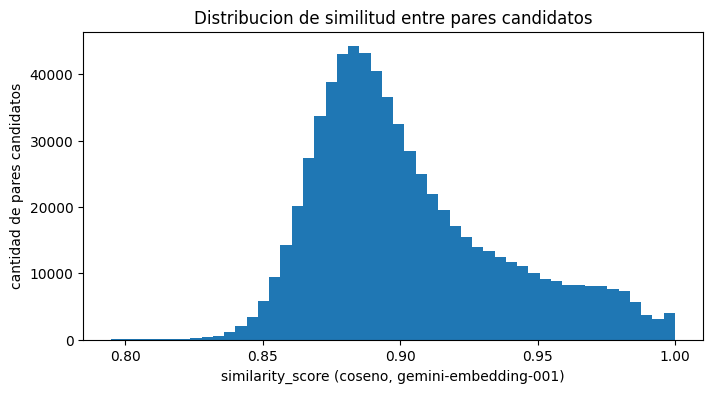

Umbral de clusters recalibrado (percentil 90): 0.957


In [16]:
similarity_scores = candidates["similarity_score"].to_numpy()
print(pd.Series(similarity_scores).describe())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(similarity_scores, bins=50)
ax.set_xlabel(f"similarity_score (coseno, {EMBEDDING_MODEL})")
ax.set_ylabel("cantidad de pares candidatos")
ax.set_title("Distribucion de similitud entre pares candidatos")
plt.show()

SIMILARITY_THRESHOLD_FOR_CLUSTERS = float(np.quantile(similarity_scores, 0.90))
print(f"Umbral de clusters recalibrado (percentil 90): {SIMILARITY_THRESHOLD_FOR_CLUSTERS:.3f}")

### 2.6 Clusters exploratorios

Como primer acercamiento a los subespacios semanticos, armamos componentes conectadas entre fragmentos con
similitud mayor al umbral recalibrado arriba. No es clustering definitivo; sirve para inspeccionar grupos
de normas potencialmente relacionadas.

In [17]:
def connected_components_from_candidates(candidates: pd.DataFrame, threshold: float) -> pd.DataFrame:
    graph = defaultdict(set)
    strong_edges = candidates[candidates["similarity_score"] >= threshold]

    for _, row in strong_edges.iterrows():
        graph[row["fragment_a_id"]].add(row["fragment_b_id"])
        graph[row["fragment_b_id"]].add(row["fragment_a_id"])

    visited = set()
    clusters = []
    cluster_id = 0

    for node in graph:
        if node in visited:
            continue
        queue = deque([node])
        visited.add(node)
        component = []
        while queue:
            current = queue.popleft()
            component.append(current)
            for neighbor in graph[current]:
                if neighbor not in visited:
                    visited.add(neighbor)
                    queue.append(neighbor)
        if len(component) >= 2:
            cluster_id += 1
            clusters.append({
                "cluster_id": f"cluster:{cluster_id:04d}",
                "size": len(component),
                "fragment_ids": component,
            })

    return pd.DataFrame(clusters).sort_values("size", ascending=False).reset_index(drop=True) if clusters else pd.DataFrame(columns=["cluster_id", "size", "fragment_ids"])


clusters = connected_components_from_candidates(candidates, SIMILARITY_THRESHOLD_FOR_CLUSTERS)
print(f"Clusters exploratorios: {len(clusters):,}")
display(clusters.head(20))

Clusters exploratorios: 8,942


,cluster_id,size,fragment_ids
0,cluster:0065,3330,"[frag:00052768, frag:00060474, frag:00107637, frag:00108342, frag:00107893, frag:00056528, frag:00108303, frag:00107622, frag:00017839, frag:00107814, frag:00103866, frag:00107805, frag:00060472, frag:00059780, frag:..."
1,cluster:0107,1109,"[frag:00050874, frag:00053723, frag:00053609, frag:00008806, frag:00071788, frag:00053673, frag:00071907, frag:00026029, frag:00006494, frag:00009650, frag:00052037, frag:00051131, frag:00051215, frag:00053709, frag:..."
2,cluster:0773,526,"[frag:00014224, frag:00112529, frag:00078230, frag:00112534, frag:00086900, frag:00112531, frag:00112539, frag:00074015, frag:00112527, frag:00112538, frag:00112533, frag:00112528, frag:00112540, frag:00112535, frag:..."
3,cluster:0129,499,"[frag:00112326, frag:00040913, frag:00088959, frag:00006279, frag:00040640, frag:00057614, frag:00081977, frag:00077044, frag:00012884, frag:00009874, frag:00084824, frag:00065522, frag:00079110, frag:00057423, frag:..."
4,cluster:0985,266,"[frag:00082290, frag:00020919, frag:00057121, frag:00023434, frag:00082301, frag:00111757, frag:00020923, frag:00023403, frag:00035059, frag:00021511, frag:00057125, frag:00082303, frag:00082277, frag:00049079, frag:..."
5,cluster:0163,184,"[frag:00071793, frag:00071634, frag:00071771, frag:00071716, frag:00056376, frag:00094917, frag:00071640, frag:00071868, frag:00004995, frag:00071820, frag:00071607, frag:00071862, frag:00071613, frag:00022765, frag:..."
6,cluster:0212,156,"[frag:00013010, frag:00025509, frag:00018502, frag:00066349, frag:00030052, frag:00018892, frag:00066555, frag:00013111, frag:00003022, frag:00066642, frag:00066481, frag:00020843, frag:00105552, frag:00066462, frag:..."
7,cluster:0369,132,"[frag:00043610, frag:00050307, frag:00069760, frag:00054081, frag:00077848, frag:00009764, frag:00036658, frag:00030865, frag:00113797, frag:00079531, frag:00006517, frag:00046852, frag:00027520, frag:00030586, frag:..."
8,cluster:0302,118,"[frag:00101288, frag:00106092, frag:00059141, frag:00092797, frag:00101139, frag:00089812, frag:00012781, frag:00106973, frag:00092813, frag:00092537, frag:00091974, frag:00105021, frag:00106275, frag:00012797, frag:..."
9,cluster:0866,115,"[frag:00021342, frag:00080912, frag:00049456, frag:00052164, frag:00048021, frag:00109320, frag:00048508, frag:00003823, frag:00109717, frag:00074595, frag:00039490, frag:00098733, frag:00078450, frag:00015849, frag:..."


In [18]:
cluster_rows = []
fragment_lookup = embedding_fragments.set_index("fragment_id")

for _, cluster in clusters.head(10).iterrows():
    for fragment_id in cluster["fragment_ids"][:10]:
        fragment = fragment_lookup.loc[fragment_id]
        cluster_rows.append({
            "cluster_id": cluster["cluster_id"],
            "cluster_size": cluster["size"],
            "fragment_id": fragment_id,
            "document_id": fragment["document_id"],
            "label": fragment["label"],
            "titulo_resumido": fragment.get("titulo_resumido", ""),
            "text_preview": fragment["text"][:500],
        })

cluster_preview = pd.DataFrame(cluster_rows)
display(cluster_preview)

,cluster_id,cluster_size,fragment_id,document_id,label,titulo_resumido,text_preview
0,cluster:0065,3330,frag:00052768,infoleg:25630,ARTICULO 3,MODIFICACION,"ARTICULO 3º — Comuníquese al Poder Ejecutivo. — ALBERTO R. PIERRI. — EDUARDO MENEM. — Esther H. Pereyra Arandía de Pérez Pardo. — Edgardo Piuzzi. DADA EN LA SALA DE SESIONES DEL CONGRESO ARGENTINO, EN BUENOS AIRES, A..."
1,cluster:0065,3330,frag:00060474,infoleg:29129,ARTICULO 3,RELIGION JUDIA,"ARTICULO 3º — Comuníquese al Poder Ejecutivo. — ALBERTO R. PIERRI. — EDUARDO MENEM. — Esther H. Pereyra Arandía de Pérez Pardo. — Edgardo Piuzzi. DADA EN LA SALA DE SESIONES DEL CONGRESO ARGENTINO, EN BUENOS AIRES, A..."
2,cluster:0065,3330,frag:00107637,infoleg:757,ARTICULO 3,EJERCICIO 1990 -APRUEBA CUENTA GENERAL-,"ARTICULO 3º — Comuníquese al Poder Ejecutivo. — ALBERTO R. PIERRI. — FAUSTINO MAZZUCCO. — Esther H. Pereyra Arandía de Pérez Pardo. — Juan J. Canals. DADA EN LA SALA DE SESIONES DEL CONGRESO ARGENTINO, EN BUENOS AIRE..."
3,cluster:0065,3330,frag:00108342,infoleg:771,ARTICULO 3,DIA NACIONAL DE LUCHA EN CONTRA DE LAS DISCRIMINACIONES,"ARTICULO 3º - Comuníquese al Poder Ejecutivo. - ALBERTO R. PIERRI. - EDUARDO MENEM. - Esther H. Pereyra Arandía de Pérez Pardo. - Edgardo Piuzzi. DADA EN LA SALA DE SESIONES DEL CONGRESO ARGENTINO, EN BUENOS AIRES, A..."
4,cluster:0065,3330,frag:00107893,infoleg:763,ARTICULO 6,JUSTICIA -CREASE DEFENSORIA DE POBRES EN LA PLATA-,"ARTICULO 6º- Comuníquese al Poder Ejecutivo.-ALBERTO R. PIERRI.-EDUARDO MENEM.-Esther H. Pereyra Arandía de Pérez Pardo.-Edgardo Piuzzi. DADA EN LA SALA DE SESIONES DEL CONGRESO ARGENTINO, EN BUENOS AIRES, A UN DIA D..."
...,...,...,...,...,...,...,...
95,cluster:0866,115,frag:00109320,infoleg:79831,ARTICULO 13,PROGRAMA NACIONAL DE SALUD SEXUAL...,ARTICULO 13. — Se invita a las provincias y a la Ciudad Autónoma de Buenos Aires a adherir a las disposiciones de la presente ley.
96,cluster:0866,115,frag:00048508,infoleg:241139,ARTICULO 19,REGIMEN DE PROMOCION DE LOS CLUBES DE BARRIO Y DE PUEBLO,ARTÍCULO 19. — Invitación. Invítese a las provincias y a la Ciudad Autónoma de Buenos Aires a adherir a la presente ley.
97,cluster:0866,115,frag:00003823,infoleg:116424,ARTICULO 13,CARGOS ESPECIFICOS - CREACION,"ARTICULO 13. — Invítase a las provincias, la Ciudad Autónoma de Buenos Aires y los municipios a adherir a las estipulaciones de la presente ley, en cuyo caso, los instrumentos normativos que formulen la adhesión resp..."
98,cluster:0866,115,frag:00109717,infoleg:81041,ARTICULO 3,LEY 22431 - MODIFICACION,ARTICULO 3° — Invítase a las provincias y a la Ciudad Autónoma de Buenos Aires a adherir a la presente ley.


### 2.7 Reduccion de dimensionalidad (PCA / t-SNE)

Se proyectan los embeddings a 2D sobre una muestra manejable (hasta 10.000 fragmentos), coloreando por
`tipo_norma` y por decada de sancion, para explorar visualmente los subespacios semanticos del corpus.
Se usa t-SNE (en vez de UMAP) para evitar la dependencia opcional de `umap-learn` con `torch`, que en
esta maquina genera un conflicto de DLLs nativas de Windows al convivir con `faiss`/`tensorflow` en el
mismo proceso. Como los embeddings ya estan L2-normalizados, la distancia euclidea por defecto de t-SNE
es equivalente (preserva el orden) a la distancia coseno.

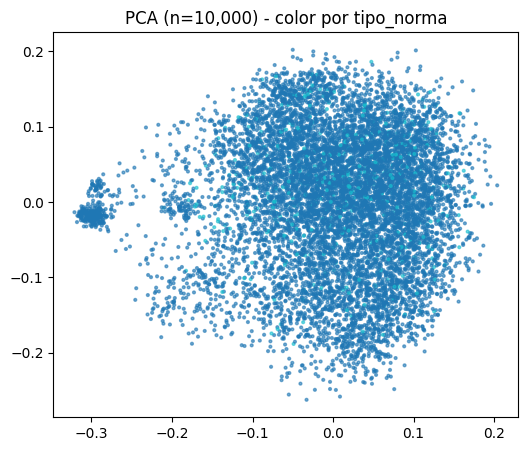

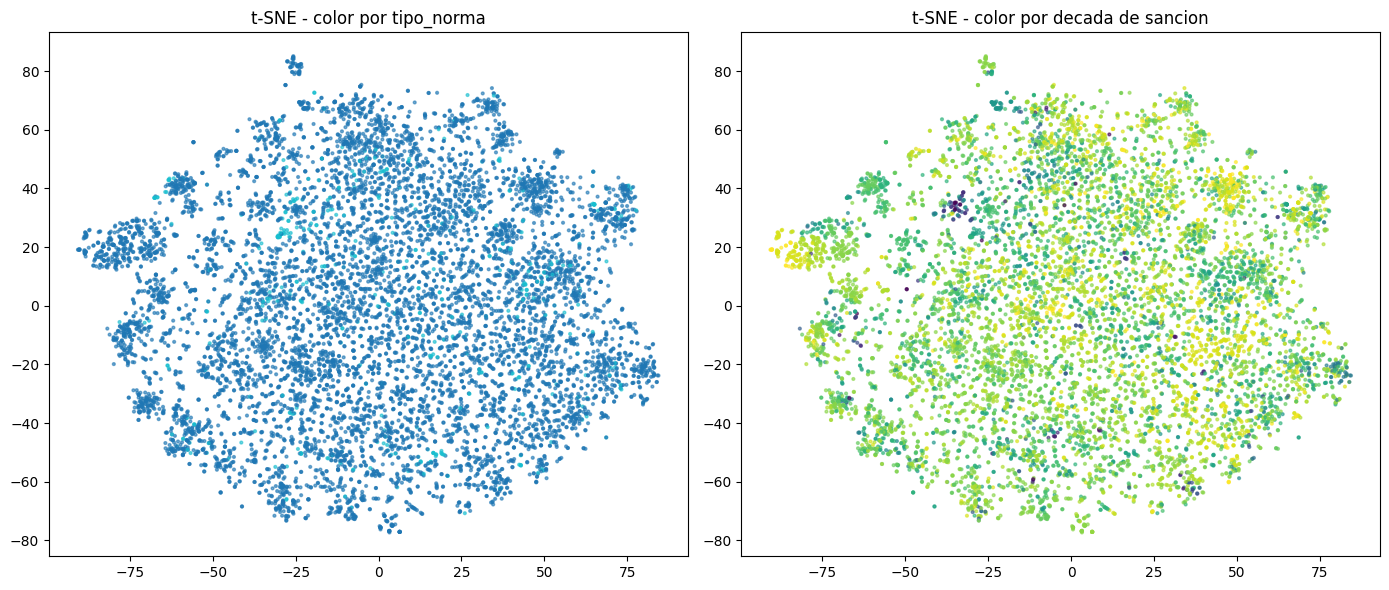

In [19]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

VIZ_SAMPLE_SIZE = min(10_000, len(embedding_fragments))
viz_positions = embedding_fragments.sample(VIZ_SAMPLE_SIZE, random_state=RANDOM_SEED).index.to_numpy()
viz_fragments = embedding_fragments.loc[viz_positions].reset_index(drop=True)
viz_embeddings = embeddings[viz_positions]

viz_fragments["decada_sancion"] = (
    pd.to_datetime(viz_fragments["fecha_sancion"], errors="coerce").dt.year // 10 * 10
)
tipo_codes, tipo_labels = pd.factorize(viz_fragments["tipo_norma"].fillna("Sin dato"))

pca_coords = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(viz_embeddings)

fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(pca_coords[:, 0], pca_coords[:, 1], c=tipo_codes, cmap="tab10", s=4, alpha=0.6)
ax.set_title(f"PCA (n={VIZ_SAMPLE_SIZE:,}) - color por tipo_norma")
plt.show()

tsne = TSNE(n_components=2, random_state=RANDOM_SEED, init="pca", perplexity=min(30, VIZ_SAMPLE_SIZE - 1))
tsne_coords = tsne.fit_transform(viz_embeddings)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(tsne_coords[:, 0], tsne_coords[:, 1], c=tipo_codes, cmap="tab10", s=4, alpha=0.6)
axes[0].set_title("t-SNE - color por tipo_norma")
axes[1].scatter(tsne_coords[:, 0], tsne_coords[:, 1], c=viz_fragments["decada_sancion"], cmap="viridis", s=4, alpha=0.6)
axes[1].set_title("t-SNE - color por decada de sancion")
plt.tight_layout()
plt.show()

### 2.8 Comparacion sanity: hashing vs gemini-embedding-001

Sobre la misma muestra chica, se recuperan vecinos con ambos metodos de embedding y se comparan los pares
top a ojo. Sirve como evidencia directa para el informe de que el modelo semantico mejora sobre el
baseline de hashing.

In [20]:
SANITY_SAMPLE_SIZE = min(2_000, len(embedding_fragments))
sanity_positions = embedding_fragments.sample(SANITY_SAMPLE_SIZE, random_state=RANDOM_SEED).index.to_numpy()
sanity_fragments = embedding_fragments.loc[sanity_positions].reset_index(drop=True)
sanity_gemini_embeddings = embeddings[sanity_positions]
sanity_hashing_embeddings = hashing_embeddings(sanity_fragments["text"].tolist())

gemini_candidates = top_neighbors_faiss(
    sanity_gemini_embeddings, sanity_fragments, top_k=3, retrieval_method=EMBEDDING_MODEL, include_text=True
)
hashing_candidates = top_neighbors_faiss(
    sanity_hashing_embeddings, sanity_fragments, top_k=3, retrieval_method="hashing_tfidf", include_text=True
)

preview_cols = ["similarity_score", "title_a", "title_b", "text_a", "text_b"]

print(f"=== Top 20 pares - {EMBEDDING_MODEL} (muestra de {SANITY_SAMPLE_SIZE:,}) ===")
display(gemini_candidates.sort_values("similarity_score", ascending=False)[preview_cols].head(20))

print("=== Top 20 pares - baseline de hashing (misma muestra) ===")
display(hashing_candidates.sort_values("similarity_score", ascending=False)[preview_cols].head(20))

=== Top 20 pares - gemini-embedding-001 (muestra de 2,000) ===


,similarity_score,title_a,title_b,text_a,text_b
0,0.998762,CONVENIO 150 DE LA OIT,TRABAJO A DOMICILIO,Artículo 12 1. Este Convenio obligará únicamente a aquellos Miembros de la Organización Internacional del Trabajo cuyas ratificaciones haya registrado el Director General. 2. Entrará en vigor doce meses después de la...,Artículo 12 1. Este Convenio obligará únicamente a aquellos Miembros de la Organización Internacional del Trabajo cuyas ratificaciones haya registrado el Director General de la Oficina Internacional del Trabajo. 2. E...
1,0.997984,CONVENIO INTERNACIONAL,CONVENIO INTERNACIONAL DEL AZUCAR,"Artículo 3 Continuación, sede y estructura de la Organización Internacional del Azúcar 1. La Organización Internacional del Azúcar establecida en virtud del Convenio Internacional del Azúcar, 1968, y mantenida en vir...","Artículo 3 Continuación, sede y estructura de la Organización Internacional del Azúcar 1. La Organización Internacional del Azúcar establecida en virtud del Convenio Internacional del Azúcar, 1968, y mantenida en vir..."
2,0.996753,JUBILACIONES-PENSIONES-REGIMENES JUBILATORIOS ESPECIALES-EMPLEADOS PUBLICOS,JUBILACIONES Y PENSIONES,ARTICULO 5.- El porcentaje establecido en el artículo anterior no se modificará aunque la edad o antiguedad acreditada excediera los mínimos fijados en el artículo 3.,ARTICULO 5º — El porcentaje establecido en el artículo anterior no se modificará aunque la edad o antigüedad acreditada excediera los mínimos fijados en el artículo 3º.
3,0.994005,MEDALLISTAS OLIMPICOS - PENSION VITALICIA,PRIMEROS PUESTOS EN JUEGOS OLIMPICOS,"ARTICULO 1º — En virtud de haber logrado títulos olímpicos o paralímpicos que quedan en la historia mundial, para la gloria del deporte argentino, quienes han obtenido u obtengan el primero, segundo o tercer puesto (...","Artículo 1°: En virtud de haber logrado títulos olímpicos o paralímpicos que quedan en la historia mundial, para la gloria del deporte argentino, quienes han obtenido u obtengan el primero, segundo o tercer puesto (m..."
4,0.990592,LEY N° 24.660 - MODIFICACION,SU EJECUCION - CARACTERISTICAS,"Artículo 135: Restricciones prohibidas al derecho a la educación. El acceso a la educación en todos sus niveles y modalidades no admitirá limitación alguna fundada en motivos discriminatorios, ni en la situación proc...","ARTICULO 135. — Restricciones prohibidas al derecho a la educación. El acceso a la educación en todos sus niveles y modalidades no admitirá limitación alguna fundada en motivos discriminatorios, ni en la situación pr..."
5,0.984748,TRATADO DE ARBITRAJE ENTRE ARGENTINA Y FRANCIA - APROBACION,TRATADO DE ARBITRAJE CON ECUADOR - SE PROMULGA LEY,"ARTICULO II En cada caso particular, las Altas Partes Contratantes firmarán un compromiso especial determinando el objeto del litigio, la sede del tribunal, el idioma de que se hará uso y aquellos cuyo uso será autor...","ARTÍCULO II En cada caso las Altas Partes Contratantes firmarán un compromiso especial que determine el objeto del litigio, y, si fuere necesario, el asiento del Tribunal, el idioma de que éste hará uso, así como los..."
6,0.982811,MODIFICACION DE LA LEY 23548,CAPTURA A TRAVES DE REDES -PROHIBICION-,"ARTICULO 2º- Comuníquese al Poder Ejecutivo nacional. DADA EN LA SALA DE SESIONES DEL CONGRESO ARGENTINO, EN BUENOS AIRES, A LOS ONCE DIAS DEL MES DE NOVIEMBRE DEL AÑO MIL NOVECIENTOS NOVENTA Y OCHO. -REGISTRADO BAJO...","ARTICULO 7º- Comuníquese al Poder Ejecutivo. DADA EN LA SALA DE SESIONES DEL CONGRESO ARGENTINO, EN BUENOS AIRES, A LOS ONCE DIAS DEL MES DE NOVIEMBRE DEL AÑO MIL NOVECIENTOS NOVENTA Y OCHO. -REGISTRADO BAJO EL Nº 25..."
7,0.982807,PESCA - NUEVO REGIMEN,LEY N° 24.922 - MODIFICACION,"ARTICULO 58.- En caso de reincidencia dentro de los cinco (5) años de cometida una infracción, los mínimos y máximos establecidos en el último párrafo del artículo 51 bis se duplicarán, sin perjuicio de la pena mayor...","Artículo 58: En caso de reincidencia dentro de los cinco (5) años de comet

=== Top 20 pares - baseline de hashing (misma muestra) ===


,similarity_score,title_a,title_b,text_a,text_b
0,1.000000,PLAGUICIDAS - EXPROPIACION,COMISION TECNICA ASESORA DE POLITICA SALARIAL - CREACION,"Artículo 8°.- Comuníquese, publíquese, dése a la Dirección Nacional del Registro Oficial y archívese. Onganía. - Adalbert Krieger Vasena","Artículo 12. — Comuníquese, publíquese, dése a la Dirección Nacional del Registro Oficial y archívese. Onganía. — Adalbert Krieger Vasena"
1,1.000000,APROBACION,LEY ORGANICA,Artículo 3°- (Artículo derogado por art. 4° del Decreto N° 257/2015 B.O. 29/12/2015),ARTÍCULO 79. — (Artículo derogado por art. 6° del Decreto N° 257/2015 B.O. 29/12/2015)
2,0.994680,APROBACION CONVENIO O.I.T. N° 159,CONVENIO SOBRE PREVENCIÓN Y CONTROL DE LOS RIESGOS POR AGENTES CANCERIGENOS - APROBACION,"ARTICULO 16 1. En caso de que la Conferencia adopte un nuevo convenio que implique una revisión total o parcial del presente, y a menos que el nuevo convenio contenga disposiciones en contrario: a) La ratificación, p...","Artículo 13 1. En caso de que la Conferencia adopte un nuevo convenio que implique una revisión total o parcial del presente, y a menos que el nuevo convenio contenga disposiciones en contrario: a) la ratificación, p..."
3,0.978820,TRABAJO A DOMICILIO,CONVENIO 150 DE LA OIT,Artículo 12 1. Este Convenio obligará únicamente a aquellos Miembros de la Organización Internacional del Trabajo cuyas ratificaciones haya registrado el Director General de la Oficina Internacional del Trabajo. 2. E...,Artículo 12 1. Este Convenio obligará únicamente a aquellos Miembros de la Organización Internacional del Trabajo cuyas ratificaciones haya registrado el Director General. 2. Entrará en vigor doce meses después de la...
4,0.961983,RELACIONES CONSULARES - CONVENCION DE VIENA DE 1963,CONVENCION CONTRA LA TORTURA - SU APROBACION,Artículo 77 Entrada en vigor 1. La presente Convención entrará en vigor el trigésimo día a partir de la fecha en que haya sido depositado en poder del Secretario General de las Naciones Unidas el vigésimo segundo ins...,ARTICULO 27 1. La presente convención entrará en vigor el trigésimo día a partir de la fecha en que haya sido depositado el vigésimo instrumento de ratificación o de adhesión en poder del secretario general de las Na...
5,0.961824,BENEFICIOS PERSONAL PASADO A DISPONIBILIDAD Y RETIRO 1960-61,PIROTECNIA - PROHIBIDA SU VTA A MENORES DE 16 AÑOS,"ARTICULO 4º — Comuníquese al Poder Ejecutivo Nacional. — ALBERTO R. PIERRI. — ORALDO BRITOS. — Esther H. Pereyra Arandía de Pérez Pardo. — Edgardo Piuzzi. DADA EN LA SALA DE SESIONES DEL CONGRESO ARGENTINO, EN BUENOS...","ARTICULO 11. - Comuníquese al Poder Ejecutivo. .- ALBERTO R. PIERRI — ORALDO BRITOS — Esther H. Pereyra Arandía de Pérez Pardo. — Edgardo Piuzzi. DADA EN LA SALA DE SESIONES DEL CONGRESO ARGENTINO, EN BUENOS AIRES. A..."
6,0.959934,MODIFICACION DE LA LEY 23548,CAPTURA A TRAVES DE REDES -PROHIBICION-,"ARTICULO 2º- Comuníquese al Poder Ejecutivo nacional. DADA EN LA SALA DE SESIONES DEL CONGRESO ARGENTINO, EN BUENOS AIRES, A LOS ONCE DIAS DEL MES DE NOVIEMBRE DEL AÑO MIL NOVECIENTOS NOVENTA Y OCHO. -REGISTRADO BAJO...","ARTICULO 7º- Comuníquese al Poder Ejecutivo. DADA EN LA SALA DE SESIONES DEL CONGRESO ARGENTINO, EN BUENOS AIRES, A LOS ONCE DIAS DEL MES DE NOVIEMBRE DEL AÑO MIL NOVECIENTOS NOVENTA Y OCHO. -REGISTRADO BAJO EL Nº 25..."
7,0.959759,CONVENIO INTERNACIONAL,CONVENIO INTERNACIONAL DEL AZUCAR,"Artículo 3 Continuación, sede y estructura de la Organización Internacional del Azúcar 1. La Organización Internacional del Azúcar establecida en virtud del Convenio Internacional del Azúcar, 1968, y mantenida en vir...","Artículo 3 Continuación, sede y estructura de la Organización Internacional del Azúcar 1. La Organización Internacional del Azúcar establecida en virtud del Convenio Internacional del Azúcar, 1968, y mantenida en vir..."
8,0.958685,LEY N° 24.660 - MODIFICACION,SU EJECUCION - CARACTERISTICAS,"Artículo 135: Restricciones prohibidas al derecho a la educación. El acceso 

## Resultado de fases 1 y 2

Este notebook deja implementado, sobre el corpus completo (`data/lexar_datos_infoleg_saij/`):

- carga y union del corpus procesado con metadatos, con seleccion de una version por documento;
- segmentacion en articulos/chunks y export de `outputs/legal_fragments.parquet`;
- embeddings semanticos con Vertex AI (`gemini-embedding-001`), con checkpointing reanudable en
  `outputs/embeddings/part_*.parquet` y consolidacion en `outputs/embeddings.npy` +
  `outputs/embedding_fragments.parquet`;
- recuperacion de vecinos cercanos con FAISS y export de `outputs/analysis_candidates.parquet`
  (+ `outputs/analysis_candidates_top.csv` para inspeccion manual);
- recalibracion del umbral de clusters exploratorios a partir de la distribucion real de similitud;
- reduccion de dimensionalidad (PCA/t-SNE) para inspeccionar visualmente el corpus;
- comparacion sanity entre el baseline de hashing y los embeddings semanticos.

La fase siguiente deberia tomar `outputs/analysis_candidates.parquet` y clasificar cada par con un prompt
juridico/PLN que devuelva `possible_conflict`, `possible_overlap`, `possible_modification`,
`different_scope`, `neutral` o `needs_review`, junto con una explicacion y una propuesta de redaccion
alternativa.